# Scatter Diagrams and Correlation: Python Companion
**ENGR 1451/2451 · Exploratory Data Science · Fall 2026**

Complete this notebook **after the slides**. Use the Auto MPG data to make a scatter diagram, calculate Pearson's $r$, work in standard units, check a unit change, and then compare correlations among several numerical variables.

This version intentionally avoids grouping so the code stays focused on **scatterplots and correlation**.

## 1. Load the Auto MPG data

Each row is one vehicle. We will focus on five numerical measurements:

- `mpg`: fuel economy in miles per gallon
- `displacement`: engine displacement
- `horsepower`: engine horsepower
- `weight`: vehicle weight in pounds
- `acceleration`: acceleration time in seconds

Keep `data/auto.csv` in a `data` folder beside this notebook.

For the multivariable comparison later, we drop rows missing **any** of the five selected measurements so every correlation uses the same vehicles.


In [1]:
# Run only when needed, then restart the kernel:
# %pip install -r requirements.txt

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
data_file = Path("data") / "auto.csv"
mpg = pd.read_csv(data_file, na_values="?")

labels = {
    "mpg": "Fuel economy (mpg)",
    "displacement": "Engine displacement (cu. in.)",
    "horsepower": "Horsepower",
    "weight": "Weight (lb)",
    "acceleration": "Acceleration time (s)",
}
feature_cols = list(labels)

mpg_complete = mpg[feature_cols].dropna()

print(f"Vehicles in data: {len(mpg)}")
print(f"Complete rows for these five measurements: {len(mpg_complete)}")
display(mpg_complete.head())


Vehicles in data: 397
Complete rows for these five measurements: 392


,mpg,displacement,horsepower,weight,acceleration
0,18.0,307.0,130.0,3504,12.0
1,15.0,350.0,165.0,3693,11.5
2,18.0,318.0,150.0,3436,11.0
3,16.0,304.0,150.0,3433,12.0
4,17.0,302.0,140.0,3449,10.5


## 2. Start with one scatter diagram

Use **vehicle weight** as $x$ and **fuel economy** as $y$. Each point represents one vehicle.

**Before calculating:** Do you expect a positive or negative correlation? Does the relationship look roughly linear? Are there any unusual points?

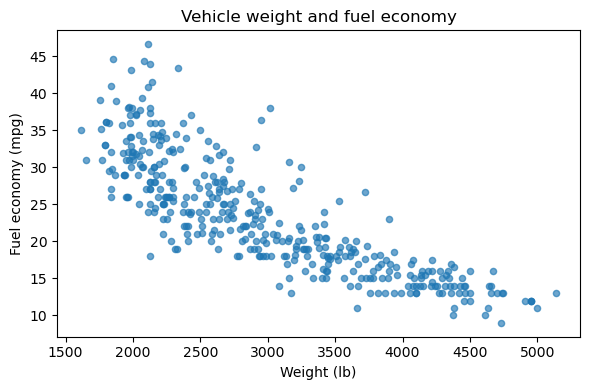

In [3]:
xcol = "weight"
ycol = "mpg"

pair = mpg[[xcol, ycol]].dropna()

ax = pair.plot.scatter(x=xcol, y=ycol, alpha=0.65, figsize=(6, 4))
ax.set(
    xlabel=labels[xcol],
    ylabel=labels[ycol],
    title="Vehicle weight and fuel economy"
)
plt.tight_layout()
plt.show()

## 3. Calculate Pearson's $r$

Keep complete **pairs** with `.dropna()` and calculate Pearson's correlation with `.corr()`.

Use `std(ddof=1)` for the sample standard deviation $s$. Compare the sign and strength of $r$ with what you saw in the scatterplot.

In [4]:
r = pair[xcol].corr(pair[ycol])

summary = pd.DataFrame({
    "Mean": pair.mean(),
    "s": pair.std(ddof=1)
})

display(summary.round(2))
print(f"n = {len(pair)}")
print(f"Pearson r = {r:.3f}")

,Mean,s
weight,2970.26,847.90
mpg,23.52,7.83


n = 397
Pearson r = -0.832


## 4. Work in standard units

Standardize each variable by subtracting its mean and dividing by its sample standard deviation:

$$
z_x=\frac{x-\bar{x}}{s_x},\qquad
z_y=\frac{y-\bar{y}}{s_y}.
$$

After standardizing, each variable should have mean approximately **0** and sample $s$ approximately **1**. Pearson's correlation can also be computed from the paired standardized products:

$$
r=\frac{\sum_i z_{x,i}z_{y,i}}{n-1}.
$$

In [5]:
z = (pair - pair.mean()) / pair.std(ddof=1)
r_from_z = (z[xcol] * z[ycol]).sum() / (len(pair) - 1)

check = pd.DataFrame({
    "Mean": z.mean(),
    "s": z.std(ddof=1)
})
display(check.round(3))

print(f"Original measurements:      r = {r:.6f}")
print(f"Standardized measurements:  r = {z[xcol].corr(z[ycol]):.6f}")
print(f"Standardized-products form: r = {r_from_z:.6f}")

,Mean,s
weight,0.0,1.0
mpg,0.0,1.0


Original measurements:      r = -0.831739
Standardized measurements:  r = -0.831739
Standardized-products form: r = -0.831739


### Check a unit change

**Predict first:** Will $r$ change if vehicle weight is converted from pounds to kilograms?

The numerical values, mean, and standard deviation of weight change, but correlation does not change under a positive rescaling.

In [6]:
kilograms_per_pound = 0.45359237
weight_kg = pair[xcol] * kilograms_per_pound

r_lb = pair[xcol].corr(pair[ycol])
r_kg = weight_kg.corr(pair[ycol])

print(f"Weight in pounds:    r = {r_lb:.6f}")
print(f"Weight in kilograms: r = {r_kg:.6f}")
print(f"Same correlation? {np.isclose(r_lb, r_kg)}")

Weight in pounds:    r = -0.831739
Weight in kilograms: r = -0.831739
Same correlation? True


## 5. Look at several variables together

A single $r$ describes only **one pair** of variables. With several numerical measurements, two related tools become useful:

- A **scatterplot matrix** shows the observations for every pair.
- A **correlation matrix** gives Pearson's $r$ for every pair.

Always inspect the scatterplots as well as the coefficients. Correlation summarizes **linear** association and can hide curves, clusters, and outliers.

### A. Scatterplot matrix

Use the same complete rows for all five measurements. `pd.plotting.scatter_matrix()` shows every pair of variables, with histograms on the diagonal.

**Quick check:** Which pairs appear most strongly related? Which relationships seem weaker or less linear?

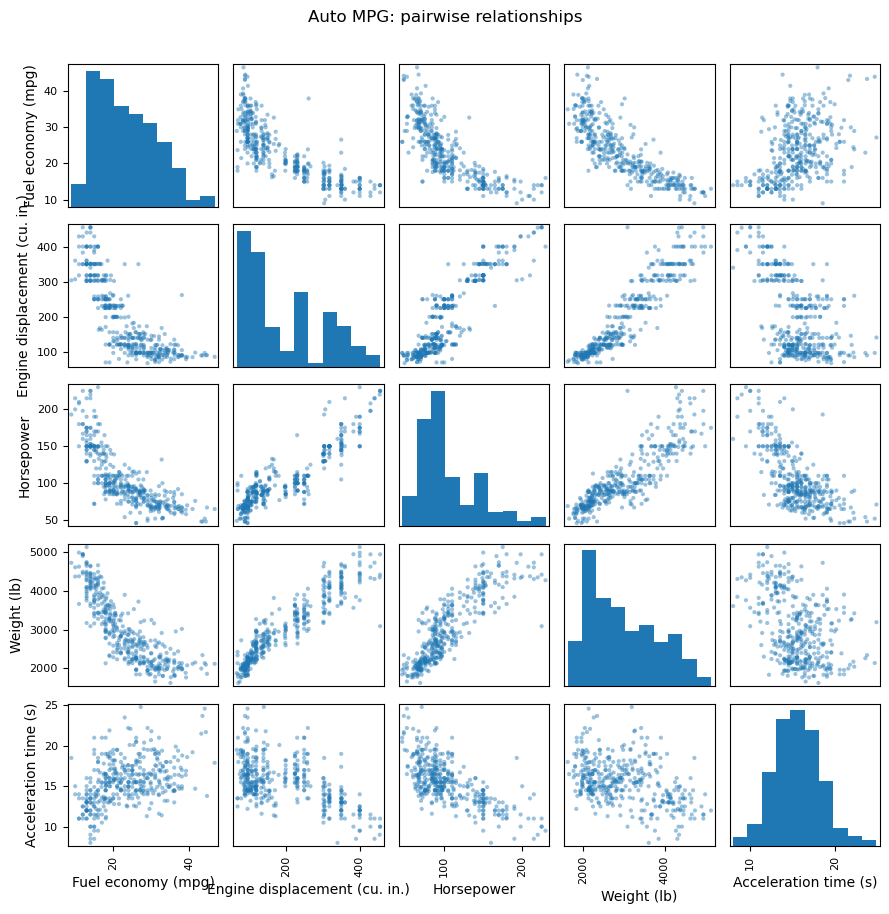

In [7]:
plot_data = mpg_complete.rename(columns=labels)

axes = pd.plotting.scatter_matrix(
    plot_data,
    figsize=(9, 9),
    diagonal="hist",
    alpha=0.45
)
plt.suptitle("Auto MPG: pairwise relationships", y=1.01)
plt.tight_layout()
plt.show()

### B. Correlation matrix

`.corr()` calculates Pearson's $r$ for every pair of selected columns.

In [8]:
mpg_complete
#mpg_complete.head()
corr = mpg_complete.corr(method="pearson")
display(corr.round(2))

,mpg,displacement,horsepower,weight,acceleration
mpg,1.00,-0.81,-0.78,-0.83,0.42
displacement,-0.81,1.00,0.90,0.93,-0.54
horsepower,-0.78,0.90,1.00,0.86,-0.69
weight,-0.83,0.93,0.86,1.00,-0.42
acceleration,0.42,-0.54,-0.69,-0.42,1.00


### C. Correlation heatmap

The heatmap shows all pairwise correlations on the same scale from $-1$ to $1$.

**Quick check:** Which pair has the strongest positive correlation? Which pair has the strongest negative correlation? Compare those cells with the corresponding scatterplots above.

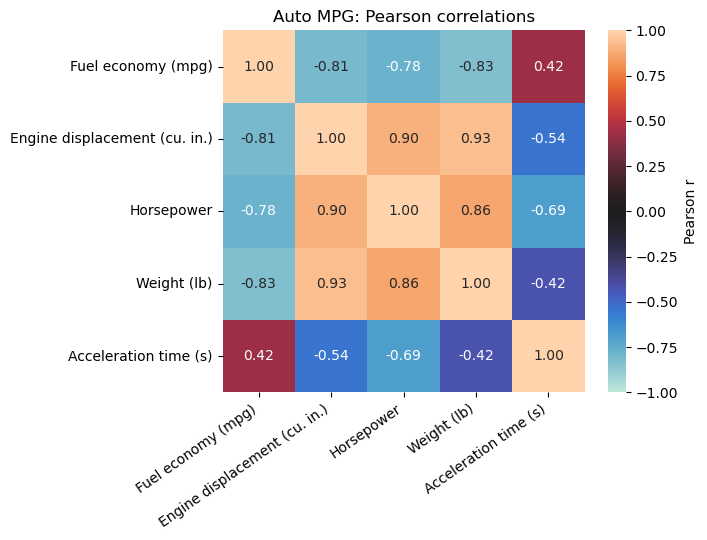

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Pearson r"},
    ax=ax
)
ax.set_title("Auto MPG: Pearson correlations")
ax.set_xticklabels([labels[col] for col in corr.columns], rotation=35, ha="right")
ax.set_yticklabels([labels[col] for col in corr.index], rotation=0)
plt.tight_layout()
plt.show()

## 6. Compact Python reference

| Task | Command |
|---|---|
| Keep complete pairs | `df[[xcol, ycol]].dropna()` |
| Scatterplot | `df.plot.scatter(x=xcol, y=ycol)` |
| Pearson correlation | `df[xcol].corr(df[ycol])` |
| Sample standard deviation | `df.std(ddof=1)` |
| Standard units | `(df - df.mean()) / df.std(ddof=1)` |
| Keep complete rows for several variables | `df[feature_cols].dropna()` |
| Scatterplot matrix | `pd.plotting.scatter_matrix(df[feature_cols])` |
| Correlation matrix | `df[feature_cols].corr()` |
| Correlation heatmap | `sns.heatmap(corr, annot=True, vmin=-1, vmax=1, center=0)` |

With missing data, `.corr()` can otherwise use different complete pairs for different coefficients. Dropping missing rows across all selected columns first makes the multivariable comparison easier to interpret.

## 7. Your turn: range restriction

Return to **weight** and **fuel economy**.

1. Report $n$ and $r$ for all vehicles with both measurements.
2. Keep only vehicles heavier than the **median weight**.
3. Report $n$ and $r$ for the restricted subset.
4. Explain what changed.

Restricting a variable's range can change correlation because you are looking at a different set of observations. Do not assume that restricting the range must always decrease $|r|$.

2800.0
397
198
-0.8317389141223784
-0.7091068693158923


Text(0.5, 0, 'Weight (lb)')

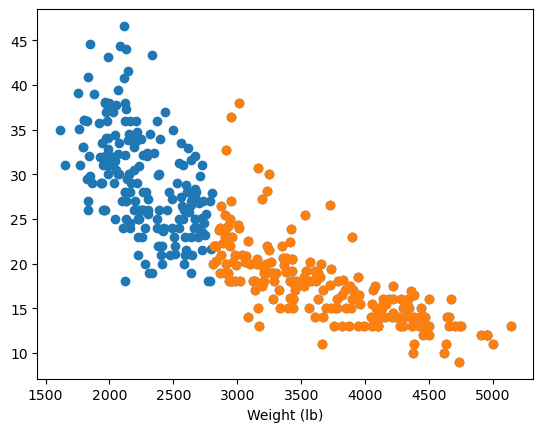

In [22]:
xcol = "weight"
ycol = "mpg"

pair = mpg[[xcol, ycol]].dropna()
cutoff_weight = pair["weight"].median()
heavy = pair.loc[pair["weight"] > cutoff_weight]

print(cutoff_weight)
print(len(pair))

print(len(restricted))

r_all = pair[xcol].corr(pair[ycol])
print(r_all)

heavy = heavy[xcol].corr(heavy[ycol])
print(r_restricted)

fig, ax = plt.subplots()
ax.scatter(pair[xcol], pair[ycol])

ax.scatter(restricted[xcol], restricted[ycol])
ax.set_xlabel("Weight (lb)")
# Your code:
# 1. Report n and r for pair.
# 2. Report n and r for restricted.
# 3. Optional: make scatterplots to compare the two sets of vehicles.

**Your interpretation:** How did the correlation change after restricting vehicle weight? Use the scatterplots to explain why. Describe association, not causal effects.

_Write two or three sentences here._

### Sources and data note

The Auto MPG copy used here is based on the [seaborn-data repository](https://github.com/mwaskom/seaborn-data/blob/master/mpg.csv). The original notebook used Iris; this version uses Auto MPG specifically to keep the correlation examples focused on numerical variables without requiring species grouping.

**Official API references:** [pandas scatter](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.scatter.html) · [pandas correlation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) · [pandas standard deviation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html) · [pandas scatter matrix](https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html) · [Seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html).
